# Hello, welcome to the "How to Train Your Own Neural Network" tutorial. 
I'm Isabella, and I should be around the room to help you figure things out. 

## Convolutional Neural Networks

We started our short lecture by describing that a convolutional neural network is a specialized type of deep learning algorithm primarily designed to recognize objects through image classification, object detection, and segmentation (as a subset of the capabilities in a field called computer vision). 

Let's get started by importing the libraries that we will need for this tutorial. We'll be using **PyTorch**, a really powerful Python library that helps us design, deploy, and control neural networks. 

In [1]:
# Setup: the libraries and settings the rest of the notebook uses

# Tools for numbers (numpy), neural networks (torch), plots (matplotlib) and images (PIL)
import time, random
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image, ImageOps
from pathlib import Path
import torch.optim as optim

# A fixed seed makes the random parts repeatable. DATA is the folder the photos download into
SEED, DATA = 0, Path("data")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Use the fastest chip available: Apple GPU (mps), NVIDIA GPU (cuda), or the CPU
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

# Photos get cut down to 128 x 128 pixels
IMG_SIZE = 128


/opt/anaconda3/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <5AA8DD3D-A2CC-31CA-8060-88B4E9C18B09> /opt/anaconda3/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <B6BD92AE-4D03-3F92-9E03-2E2594A12866> /opt/anaconda3/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


## Images as tensors

- A **tensor** is a block of numbers laid out along one or more directions, called **axes**
- Its **shape** lists how long each axis is

Here is an example of a tensor that we manually input the matrix values of:


In [2]:
# A small tensor typed in by hand: 4 rows and 4 columns
# float32 stores the numbers as decimals, the kind neural networks work with
M = torch.tensor([[1, 3, 2, 0],
                  [5, 2, 1, 1],
                  [0, 1, 8, 6],
                  [2, 4, 3, 7]], dtype=torch.float32)

# Print the numbers, then the shape: torch.Size([4, 4])
print(M, M.shape)

tensor([[1., 3., 2., 0.],
        [5., 2., 1., 1.],
        [0., 1., 8., 6.],
        [2., 4., 3., 7.]]) torch.Size([4, 4])


Great, so that is your first 1D tensor. Let's talk about N-dimensional tensors. 

In [3]:
# Stack 3 copies of M, like pages in a book
# dim=0 puts the new "pages" axis first, so the shape goes from [4, 4] to [3, 4, 4]
tensor_3d = torch.stack([M] * 3, dim=0)
print(tensor_3d, tensor_3d.shape)

tensor([[[1., 3., 2., 0.],
         [5., 2., 1., 1.],
         [0., 1., 8., 6.],
         [2., 4., 3., 7.]],

        [[1., 3., 2., 0.],
         [5., 2., 1., 1.],
         [0., 1., 8., 6.],
         [2., 4., 3., 7.]],

        [[1., 3., 2., 0.],
         [5., 2., 1., 1.],
         [0., 1., 8., 6.],
         [2., 4., 3., 7.]]]) torch.Size([3, 4, 4])


What we see now is that this tensor that used to be one-dimensional is now three-dimensional. Why is this important? It is because, with most computer vision things, there are many dimensions. Secondly, images that are in color are usually in three dimensions: red, green, blue. 

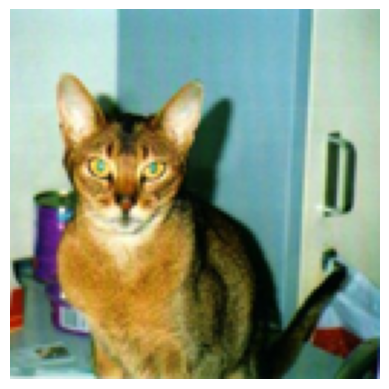

In [4]:
# Open a cat photo from the pet dataset, crop it to a 128 x 128 square, and show it
cat = ImageOps.fit(Image.open(DATA / "oxford-iiit-pet/images/Abyssinian_119.jpg").convert("RGB"),
                    (IMG_SIZE, IMG_SIZE))
plt.imshow(cat); plt.axis("off"); plt.show()

Cool. Now we see a picture of a cat that we've loaded! 
Let's make this picture of a cat into a tensor in PyTorch. 

In [5]:
# Turn the photo into a tensor: each pixel becomes numbers between 0 and 1
cat_tensor = TF.to_tensor(cat)

# Shape [3, 128, 128] = 3 color channels (red, green, blue), 128 rows, 128 columns
print(cat_tensor, cat_tensor.shape)

NameError: name 'TF' is not defined

# Visualize the cat. Visualize the tensor. 

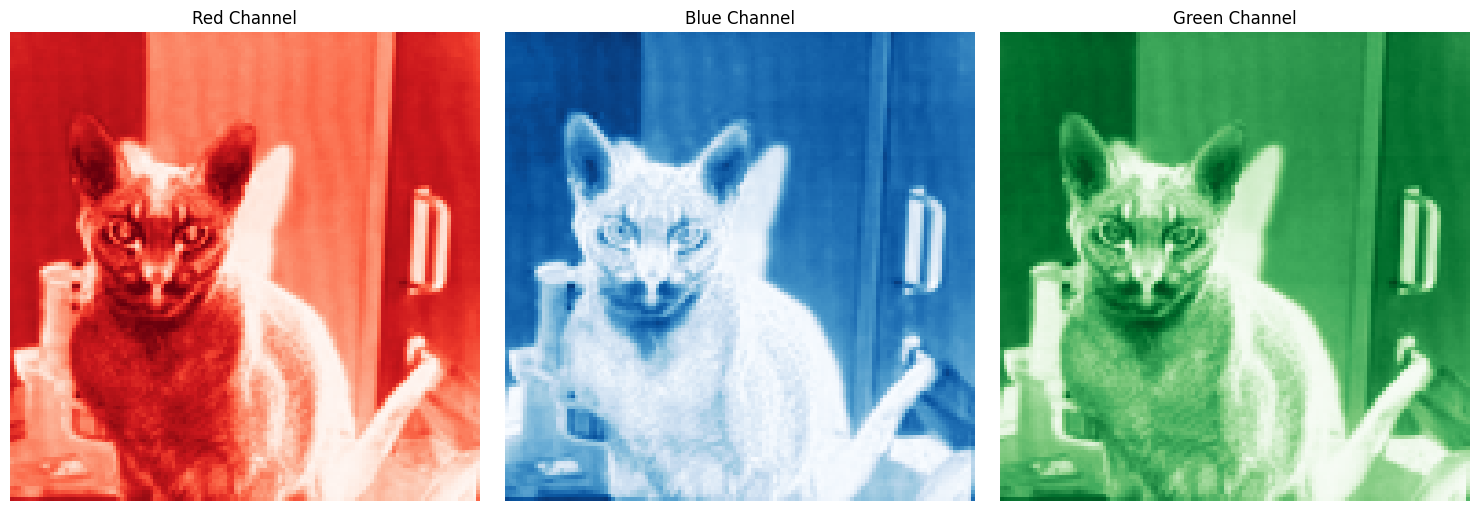

In [ ]:
# Pull out the 3 color channels. Each one is a 128 x 128 grid of numbers
r_channel = cat_tensor[0]  # Index 0: Red
g_channel = cat_tensor[1]  # Index 1: Green
b_channel = cat_tensor[2]  # Index 2: Blue

# Draw them side by side. A darker shade means more of that color
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: Red Channel
axes[0].imshow(r_channel, cmap="Reds")
axes[0].set_title("Red Channel")
axes[0].axis("off")

# Middle: Blue Channel
axes[1].imshow(b_channel, cmap="Blues")
axes[1].set_title("Blue Channel")
axes[1].axis("off")

# Right: Green Channel
axes[2].imshow(g_channel, cmap="Greens")
axes[2].set_title("Green Channel")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Great. Now we know that this cat is actually a three-dimensional tensor. What we typically do in neural networks is we load the tensors onto the neural network to start training and do inference, so let's go ahead and load the model first 

# Load the model. 

In [ ]:
# Load ResNet-18, a network that already learned from over a million photos (ImageNet)
weights = ResNet18_Weights.DEFAULT     # the numbers it learned in that training
model = resnet18(weights=weights)

# Switch to prediction mode. Since it's the last line, Jupyter also prints every layer
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# We are doing something called transfer learning. 

That means that we take a neural network that has been trained on a supercomputer, bring the model to our computer, which is relatively small, and use it to do some fine-tuning. We use a small subset of images to train a little bit more, and that way your model is fine-tuned to the specific task. 

Let's get into activation functions. 

# What is a convolution? 

Let's code just a single-layer neural network with `conv2d`, which extracts edge-like features using a 3x3 kernel. 



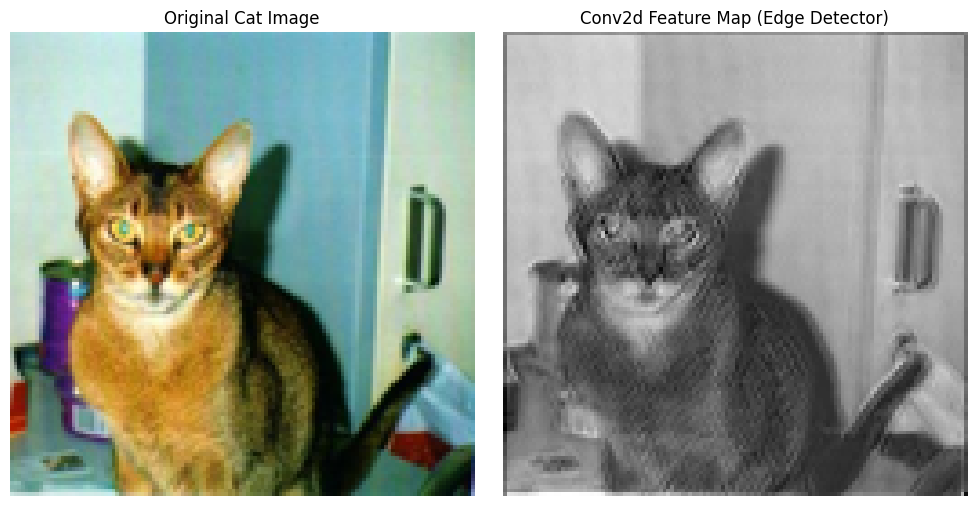

In [ ]:
# One convolution layer: a 3x3 filter slides over the photo and builds 1 feature map
# Its weights start out random. Training is what tunes filters into edge detectors
conv_layer = nn.Conv2d(
    in_channels=3,     # RGB input
    out_channels=1,    # Output 1 feature map
    kernel_size=3,     # 3x3 sliding filter
    stride=1,          # Move 1 pixel at a time
    padding=1          # Keep output height and width identical to input
)

# Pass the cat image through the Conv2d layer
# unsqueeze(0) makes a batch of 1 photo, since layers expect batches
# no_grad() skips the training bookkeeping: we're only looking
with torch.no_grad():
    output_tensor = conv_layer(cat_tensor.unsqueeze(0))

# Left: the original. permute(1, 2, 0) moves color to the end, the order matplotlib wants
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Cat Image")
plt.imshow(cat_tensor.permute(1, 2, 0).numpy())
plt.axis('off')

# Right: the feature map. squeeze() drops the size-1 axes, leaving a 128 x 128 grid
plt.subplot(1, 2, 2)
plt.title("Conv2d Feature Map (Edge Detector)")
plt.imshow(output_tensor.squeeze().numpy(), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# Conv2d

**The idea**

- Slide a small grid of numbers (a kernel or filter) across an input image or feature map
- Multiply matching numbers, add them up, and write down the result to build a new feature map

$$
(I * K)(i, j) \;=\; \sum_{m} \sum_{n} I(i + m,\ j + n) \cdot K(m, n) + b
$$

- $I(i+m, j+n)$ — the pixel values in the patch of the image currently under the filter
- $K(m, n)$ — the weights of the sliding filter (e.g., a $3 \times 3$ grid)
- $b$ — a single trainable bias value added to the final sum
- Conv2d stands for *2D Convolutional Layer*; it scans spatial patterns (like edges or textures) across height and width


$$
\frac{\partial L}{\partial K(m,n)} \;=\; \sum_{i} \sum_{j} \frac{\partial L}{\partial Y(i,j)} \cdot I(i+m, j+n)
$$

- $\frac{\partial L}{\partial K}$ — read "how changing a filter weight affects the final loss"
- $\frac{\partial L}{\partial Y(i,j)}$ — the error signal coming back from the next layer for a specific output pixel
- To calculate the gradient for a single filter weight, multiply the incoming error signal by the original input pixel that touched that weight, and sum across all positions
- During training, weights update based on the features they overlapped with: if a filter feature helped make a good prediction, its pattern becomes stronger; if it caused an error, its weights adjust to ignore that pattern


Now, just for fun, I want to pass the cat through `conv2d` and then a `relu`. 

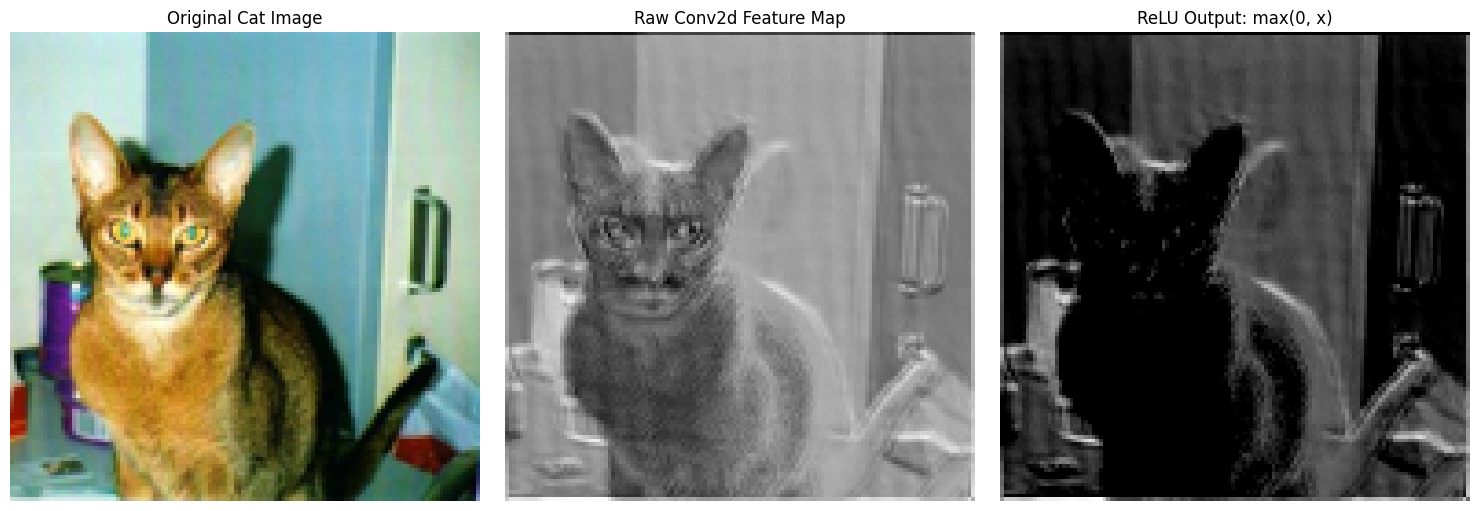

In [ ]:
# Same cat, through Conv2d and then ReLU

# Already imported at the top. Importing again is harmless
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Make the two layers
# A new Conv2d gets new random weights, so its map looks different from the one above
conv_layer = nn.Conv2d(
    in_channels=3,     # RGB input
    out_channels=1,    # Output 1 feature map
    kernel_size=3,     # 3x3 sliding filter
    stride=1,          # Move 1 pixel at a time
    padding=1          # Keep output height and width identical to input
)

relu_layer = nn.ReLU()   # turns every negative number into 0

# 2. Pass the cat image through Conv2d, then through ReLU
with torch.no_grad():
    conv_output = conv_layer(cat_tensor.unsqueeze(0))
    relu_output = relu_layer(conv_output)

# 3. Show all three side by side
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.title("Original Cat Image")
plt.imshow(cat_tensor.permute(1, 2, 0).numpy())
plt.axis('off')

# Raw Conv2d Feature Map (contains both positive and negative values)
plt.subplot(1, 3, 2)
plt.title("Raw Conv2d Feature Map")
plt.imshow(conv_output.squeeze().numpy(), cmap='gray')
plt.axis('off')

# After ReLU: the negatives are now 0, drawn as black
plt.subplot(1, 3, 3)
plt.title("ReLU Output: max(0, x)")
plt.imshow(relu_output.squeeze().numpy(), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# ReLU

**The idea**

- Go through every number in the feature map
- If it is negative, replace it with 0. Otherwise, leave it alone

$$
\mathrm{ReLU}(x) \;=\; \max(0,\ x)
$$

- $\max(0,\ x)$ — "whichever is bigger: 0 or $x$"
- ReLU stands for *Rectified Linear Unit*; "rectified" means the negative half is cut off


$$
\frac{d}{dx}\,\mathrm{ReLU}(x) \;=\;
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{if } x \le 0
\end{cases}
$$

- $\frac{d}{dx}$ — read "the slope, as $x$ changes"
- Right of zero the line is diagonal: nudge $x$ up by 1 and the output goes up by 1, so the slope is **1**
- Left of zero the line is flat: nudge $x$ and the output stays 0, so the slope is **0**
- During training, learning signals pass straight through wherever a value was positive, and are blocked wherever it was not

# MaxPool2d

**The idea**

- Slide a small grid (like a 2x2 window) across an image or feature map
- Look at the numbers inside the window, pick only the single largest (brightest) value, and discard the rest
- This downsizes the feature map, cuts down on computation, and keeps the most prominent features intact

$$
\text{Output Pixel} \;=\; \max(X_{\text{window}})
$$

- $X_{\text{window}}$ — the small patch of feature map values currently covered by the pooling window
- $\max(\dots)$ — selects the single highest value from that local group
- MaxPool2d stands for *2D Max Pooling*; it reduces spatial size (height and width) while leaving the channel depth untouched
- Provides translation invariance: if a feature (like a cat's eye) moves slightly, the local maximum stays mostly the same


$$
\frac{\partial L}{\partial X(i,j)} \;=\;
\begin{cases}
\frac{\partial L}{\partial Y} & \text{if } X(i,j) \text{ was the maximum value in the window} \\
0 & \text{otherwise}
\end{cases}
$$

- $\frac{\partial L}{\partial X(i,j)}$ — the gradient flowing back to a specific pixel in the input image/feature map
- $\frac{\partial L}{\partial Y}$ — the incoming error signal from the next layer
- During training, max pooling has no learnable weights or parameters
- It acts like a router during backpropagation: the incoming gradient routes entirely to whichever input pixel "won" the max operation, while all other pixels receive a gradient of zero

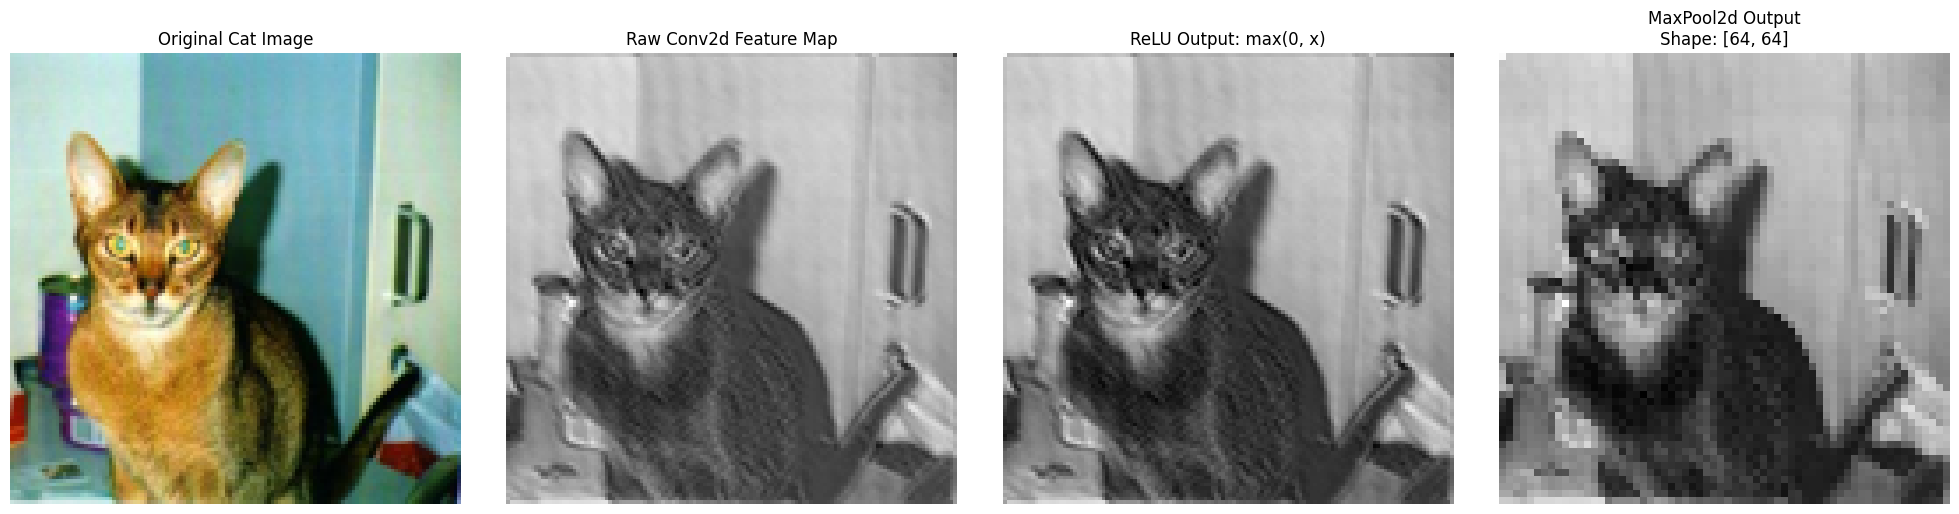

In [ ]:
# Same cat, through all three layers: Conv2d, ReLU, then MaxPool2d

# 1. Make the three layers
conv_layer = nn.Conv2d(
    in_channels=3,     # RGB input
    out_channels=1,    # Output 1 feature map
    kernel_size=3,     # 3x3 sliding filter
    stride=1,          # Move 1 pixel at a time
    padding=1          # Keep output height and width identical to input
)

relu_layer = nn.ReLU()   # negatives become 0

# MaxPool2d keeps only the biggest number in each 2x2 square
pool_layer = nn.MaxPool2d(
    kernel_size=2,     # 2x2 pooling window
    stride=2           # Jump 2 pixels, so height and width are halved
)

# 2. Pass the cat through them in order
with torch.no_grad():
    conv_output = conv_layer(cat_tensor.unsqueeze(0))
    relu_output = relu_layer(conv_output)
    pool_output = pool_layer(relu_output)

# 3. Show all four side by side
plt.figure(figsize=(20, 5))

# Original Image
plt.subplot(1, 4, 1)
plt.title("Original Cat Image")
plt.imshow(cat_tensor.permute(1, 2, 0).numpy())
plt.axis('off')

# Raw Conv2d Feature Map
plt.subplot(1, 4, 2)
plt.title("Raw Conv2d Feature Map")
plt.imshow(conv_output.squeeze().numpy(), cmap='gray')
plt.axis('off')

# Post-ReLU Feature Map
plt.subplot(1, 4, 3)
plt.title("ReLU Output: max(0, x)")
plt.imshow(relu_output.squeeze().numpy(), cmap='gray')
plt.axis('off')

# After MaxPool2d: half the size, 128 x 128 became 64 x 64
plt.subplot(1, 4, 4)
plt.title(f"MaxPool2d Output\nShape: {list(pool_output.squeeze().shape)}")
plt.imshow(pool_output.squeeze().numpy(), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

# Great. Now let's look at the whole ResNet. 

### The map of ResNet-18

- Read it left to right: the photo goes in, two scores come out
- **Hover** over any stage for a one-line summary, and **click** the sections under the map to open every layer
- Box height shows how big the picture still is — 176 × 176 at the start, a single number per feature by the end
- The curve over each `layer` is its **skip connection**, the "Res" in ResNet
- Orange stages are trained here, blue-grey stages stay frozen, grey stages have no weights at all

<div>
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1000 350" width="100%" font-family="Urbanist, -apple-system, Segoe UI, sans-serif">
<rect x="1" y="1" width="998" height="348" rx="14" fill="#fcfcfb" stroke="#e4e2dc"/>
<text x="27.0" y="30" font-size="15" font-weight="700" fill="#1a1a1a">ResNet-18, stage by stage · hover over any stage</text>
<rect x="736.4" y="20" width="12" height="12" rx="3" fill="#f2f1ec" stroke="#a8a7a2"/>
<text x="754.4" y="30" font-size="11" fill="#5f5e5a">no weights</text>
<rect x="836.4" y="20" width="12" height="12" rx="3" fill="#dfe7f1" stroke="#6f89a8"/>
<text x="854.4" y="30" font-size="11" fill="#5f5e5a">frozen</text>
<rect x="911.6" y="20" width="12" height="12" rx="3" fill="#fde3d6" stroke="#eb6834"/>
<text x="929.6" y="30" font-size="11" fill="#5f5e5a">trained</text>
<line x1="110.0" y1="150" x2="117.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="122.0,150 116.0,146 116.0,154" fill="#b5b4ae"/>
<line x1="206.0" y1="150" x2="213.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="218.0,150 212.0,146 212.0,154" fill="#b5b4ae"/>
<line x1="302.0" y1="150" x2="309.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="314.0,150 308.0,146 308.0,154" fill="#b5b4ae"/>
<line x1="398.0" y1="150" x2="405.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="410.0,150 404.0,146 404.0,154" fill="#b5b4ae"/>
<line x1="494.0" y1="150" x2="501.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="506.0,150 500.0,146 500.0,154" fill="#b5b4ae"/>
<line x1="590.0" y1="150" x2="597.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="602.0,150 596.0,146 596.0,154" fill="#b5b4ae"/>
<line x1="686.0" y1="150" x2="693.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="698.0,150 692.0,146 692.0,154" fill="#b5b4ae"/>
<line x1="782.0" y1="150" x2="789.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="794.0,150 788.0,146 788.0,154" fill="#b5b4ae"/>
<line x1="878.0" y1="150" x2="885.0" y2="150" stroke="#b5b4ae" stroke-width="1.4"/><polygon points="890.0,150 884.0,146 884.0,154" fill="#b5b4ae"/>
<g opacity="1"><title>The photo: 3 colour channels × 176 × 176 pixels</title><rect x="27.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="27.0" y="68.0" width="82" height="164.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="68.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">photo</text><text x="68.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">3 × 176 × 176</text><text x="68.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="1"><title>conv1 → batch norm → ReLU · 64 kernels, each 7 × 7 × 3, stride 2 · 9,536 weights · frozen</title><rect x="123.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="123.0" y="92.0" width="82" height="116.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<text x="164.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">conv1</text><text x="164.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 88 × 88</text><text x="164.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">9.5k</text></g>
<g opacity="1"><title>max-pool 3 × 3, stride 2 · halves height and width · no weights</title><rect x="219.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="219.0" y="109.0" width="82" height="82.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="260.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">maxpool</text><text x="260.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 44 × 44</text><text x="260.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="1"><title>layer1: 2 residual blocks, 64 → 64 channels · 147,968 weights · frozen</title><rect x="315.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="315.0" y="109.0" width="82" height="82.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 323.0 109.0 Q 356.0 81.0 389.0 109.0" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="356.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer1</text><text x="356.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">64 × 44 × 44</text><text x="356.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">148k</text></g>
<g opacity="1"><title>layer2: 2 residual blocks, 64 → 128 channels, 44 × 44 → 22 × 22 · 525,568 weights · frozen</title><rect x="411.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="411.0" y="121.0" width="82" height="58.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 419.0 121.0 Q 452.0 93.0 485.0 121.0" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="452.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer2</text><text x="452.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">128 × 22 × 22</text><text x="452.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">526k</text></g>
<g opacity="1"><title>layer3: 2 residual blocks, 128 → 256 channels, 22 × 22 → 11 × 11 · 2,099,712 weights · frozen</title><rect x="507.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="507.0" y="129.5" width="82" height="41.0" rx="7" fill="#dfe7f1" stroke="#6f89a8" stroke-width="1.6"/>
<path d="M 515.0 129.5 Q 548.0 101.5 581.0 129.5" fill="none" stroke="#6f89a8" stroke-width="1.5"/>
<text x="548.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer3</text><text x="548.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">256 × 11 × 11</text><text x="548.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">2.1M</text></g>
<g opacity="1"><title>layer4: 2 residual blocks, 256 → 512 channels, 11 × 11 → 6 × 6 · 8,393,728 weights · trained</title><rect x="603.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="603.0" y="134.9" width="82" height="30.3" rx="7" fill="#fde3d6" stroke="#eb6834" stroke-width="1.6"/>
<path d="M 611.0 134.9 Q 644.0 106.9 677.0 134.9" fill="none" stroke="#eb6834" stroke-width="1.5"/>
<text x="644.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">layer4</text><text x="644.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">512 × 6 × 6</text><text x="644.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">8.4M</text></g>
<g opacity="1"><title>average each 6 × 6 map into one number · 512 × 6 × 6 → 512 · no weights</title><rect x="699.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="699.0" y="137.0" width="82" height="26.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="740.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">avgpool</text><text x="740.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">512</text><text x="740.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<g opacity="1"><title>the head: 512 features → 2 scores · 1,026 weights · trained</title><rect x="795.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="795.0" y="137.0" width="82" height="26.0" rx="7" fill="#fde3d6" stroke="#eb6834" stroke-width="1.6"/>
<text x="836.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">fc</text><text x="836.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">2</text><text x="836.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">1.0k</text></g>
<g opacity="1"><title>the two scores, cat and dog · softmax turns them into probabilities</title><rect x="891.0" y="40" width="82" height="236" fill="#fcfcfb"/><rect x="891.0" y="137.0" width="82" height="26.0" rx="7" fill="#f2f1ec" stroke="#a8a7a2" stroke-width="1.6"/>
<text x="932.0" y="55" text-anchor="middle" font-size="13" font-weight="700" fill="#1a1a1a">2 scores</text><text x="932.0" y="252" text-anchor="middle" font-size="11" fill="#1a1a1a">cat, dog</text><text x="932.0" y="268" text-anchor="middle" font-size="11" fill="#5f5e5a">no weights</text></g>
<text x="27.0" y="294" font-size="11" fill="#5f5e5a">where the 11,177,538 weights live</text>
<g><title>conv1 + bn1 · 9,536 weights · 0.1%</title><rect x="27.0" y="301" width="0.8" height="16" fill="#d4deea" stroke="#fcfcfb" stroke-width=".8"/></g>
<g><title>layer1 · 147,968 weights · 1.3%</title><rect x="27.8" y="301" width="12.5" height="16" fill="#bccbdc" stroke="#fcfcfb" stroke-width=".8"/></g>
<g><title>layer2 · 525,568 weights · 4.7%</title><rect x="40.3" y="301" width="44.5" height="16" fill="#a5b8cf" stroke="#fcfcfb" stroke-width=".8"/></g>
<g><title>layer3 · 2,099,712 weights · 18.8%</title><rect x="84.8" y="301" width="177.7" height="16" fill="#8ea5c2" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="258.5" y="335" text-anchor="end" font-size="11" fill="#1a1a1a">layer3 · 18.8%</text>
<g><title>layer4 · 8,393,728 weights · 75.1%</title><rect x="262.5" y="301" width="710.4" height="16" fill="#eb6834" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="617.7" y="335" text-anchor="middle" font-size="11" fill="#1a1a1a">layer4 · 75.1% · trained</text>
<g><title>fc · 1,026 weights · 0.0%</title><rect x="972.9" y="301" width="0.6" height="16" fill="#eb6834" stroke="#fcfcfb" stroke-width=".8"/></g>
<text x="27.0" y="335" font-size="11" fill="#1a1a1a">conv1 → layer2 · 6.1%</text>
</svg>
</div>

<details><summary><b>The residual block</b> — the unit every <code>layer</code> is built from</summary>

- Each `layer` is 2 **residual blocks**. A block does: 3 × 3 conv → batch norm → ReLU → 3 × 3 conv → batch norm → **add the block's own input back** → ReLU
- In symbols: $y = \mathrm{ReLU}\bigl(F(x) + x\bigr)$, where $F$ is the conv–norm–ReLU–conv–norm stack
- If a block has nothing useful to add, it can learn $F(x) \approx 0$ and pass the picture through unchanged. That is what lets very deep networks train well
- When a block shrinks the picture and doubles the channels, the skip path gets a 1 × 1 conv with stride 2, so the two can still be added

</details>

<details><summary><b>Counting the weights</b> — how 11,177,538 adds up</summary>

- A conv layer with $C_{\text{out}}$ kernels, each $C_{\text{in}} \times k \times k$, has $C_{\text{out}} \times C_{\text{in}} \times k \times k$ weights. ResNet's convs have no bias
- Example from `layer1`: $64 \times 64 \times 3 \times 3 = 36,864$
- Batch norm has one $\gamma$ and one $\beta$ per channel: $2 \times C$
- The head has $512 \times 2$ weights plus 2 biases: $1,026$
- Doubling the channels in *and* out makes a conv four times bigger, which is why `layer4` alone holds 75.1% of the network

</details>

<details><summary><b>photo → conv1 → maxpool</b> · 3 × 176 × 176 → 64 × 44 × 44 · 9,536 weights · frozen</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 64 kernels, 7 × 7 × 3, stride 2, padding 3 | 64 × 88 × 88 | 9,408 |
| `bn1` | batch norm | 64 × 88 × 88 | 128 |
| `relu` | negatives become 0 | 64 × 88 × 88 | 0 |
| `maxpool` | 3 × 3 tiles, stride 2, padding 1 | 64 × 44 × 44 | 0 |

- Sizes from section 3.1's formula: $\lfloor (176 + 6 - 7) / 2 \rfloor + 1 = 88$, then $\lfloor (88 + 2 - 3) / 2 \rfloor + 1 = 44$

</details>

<details><summary><b>layer1</b> · 64 × 44 × 44 → 64 × 44 × 44 · 147,968 weights · frozen</summary>

<details><summary>block 0 · 73,984 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn1` | batch norm, then ReLU | 64 × 44 × 44 | 128 |
| `conv2` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn2` | batch norm | 64 × 44 × 44 | 128 |
| skip | add the block's input back, then ReLU | 64 × 44 × 44 | 0 |

</details>

<details><summary>block 1 · 73,984 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn1` | batch norm, then ReLU | 64 × 44 × 44 | 128 |
| `conv2` | 64 kernels, 3 × 3 × 64 | 64 × 44 × 44 | 36,864 |
| `bn2` | batch norm | 64 × 44 × 44 | 128 |
| skip | add the block's input back, then ReLU | 64 × 44 × 44 | 0 |

</details>

</details>

<details><summary><b>layer2</b> · 64 × 44 × 44 → 128 × 22 × 22 · 525,568 weights · frozen</summary>

<details><summary>block 0 · 230,144 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 128 kernels, 3 × 3 × 64, stride 2 | 128 × 22 × 22 | 73,728 |
| `bn1` | batch norm, then ReLU | 128 × 22 × 22 | 256 |
| `conv2` | 128 kernels, 3 × 3 × 128 | 128 × 22 × 22 | 147,456 |
| `bn2` | batch norm | 128 × 22 × 22 | 256 |
| skip | 1 × 1 conv (128 kernels × 64, stride 2) and batch norm, so the input fits; then add, then ReLU | 128 × 22 × 22 | 8,448 |

</details>

<details><summary>block 1 · 295,424 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 128 kernels, 3 × 3 × 128 | 128 × 22 × 22 | 147,456 |
| `bn1` | batch norm, then ReLU | 128 × 22 × 22 | 256 |
| `conv2` | 128 kernels, 3 × 3 × 128 | 128 × 22 × 22 | 147,456 |
| `bn2` | batch norm | 128 × 22 × 22 | 256 |
| skip | add the block's input back, then ReLU | 128 × 22 × 22 | 0 |

</details>

</details>

<details><summary><b>layer3</b> · 128 × 22 × 22 → 256 × 11 × 11 · 2,099,712 weights · frozen</summary>

<details><summary>block 0 · 919,040 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 256 kernels, 3 × 3 × 128, stride 2 | 256 × 11 × 11 | 294,912 |
| `bn1` | batch norm, then ReLU | 256 × 11 × 11 | 512 |
| `conv2` | 256 kernels, 3 × 3 × 256 | 256 × 11 × 11 | 589,824 |
| `bn2` | batch norm | 256 × 11 × 11 | 512 |
| skip | 1 × 1 conv (256 kernels × 128, stride 2) and batch norm, so the input fits; then add, then ReLU | 256 × 11 × 11 | 33,280 |

</details>

<details><summary>block 1 · 1,180,672 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 256 kernels, 3 × 3 × 256 | 256 × 11 × 11 | 589,824 |
| `bn1` | batch norm, then ReLU | 256 × 11 × 11 | 512 |
| `conv2` | 256 kernels, 3 × 3 × 256 | 256 × 11 × 11 | 589,824 |
| `bn2` | batch norm | 256 × 11 × 11 | 512 |
| skip | add the block's input back, then ReLU | 256 × 11 × 11 | 0 |

</details>

</details>

<details><summary><b>layer4</b> · 256 × 11 × 11 → 512 × 6 × 6 · 8,393,728 weights · trained</summary>

<details><summary>block 0 · 3,673,088 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 512 kernels, 3 × 3 × 256, stride 2 | 512 × 6 × 6 | 1,179,648 |
| `bn1` | batch norm, then ReLU | 512 × 6 × 6 | 1,024 |
| `conv2` | 512 kernels, 3 × 3 × 512 | 512 × 6 × 6 | 2,359,296 |
| `bn2` | batch norm | 512 × 6 × 6 | 1,024 |
| skip | 1 × 1 conv (512 kernels × 256, stride 2) and batch norm, so the input fits; then add, then ReLU | 512 × 6 × 6 | 132,096 |

</details>

<details><summary>block 1 · 4,720,640 weights</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `conv1` | 512 kernels, 3 × 3 × 512 | 512 × 6 × 6 | 2,359,296 |
| `bn1` | batch norm, then ReLU | 512 × 6 × 6 | 1,024 |
| `conv2` | 512 kernels, 3 × 3 × 512 | 512 × 6 × 6 | 2,359,296 |
| `bn2` | batch norm | 512 × 6 × 6 | 1,024 |
| skip | add the block's input back, then ReLU | 512 × 6 × 6 | 0 |

</details>

</details>

<details><summary><b>avgpool → fc</b> · 512 × 6 × 6 → 2 · 1,026 weights · trained</summary>

| layer | what it does | output | weights |
|:--|:--|:--|--:|
| `avgpool` | average each 6 × 6 map into one number | 512 | 0 |
| `fc` | 2 weighted sums of the 512 features | 2 | 1,026 |

</details>

train 1600   val 600   test 3669 (held out)
trainval balance:  cats 1188   dogs 2492


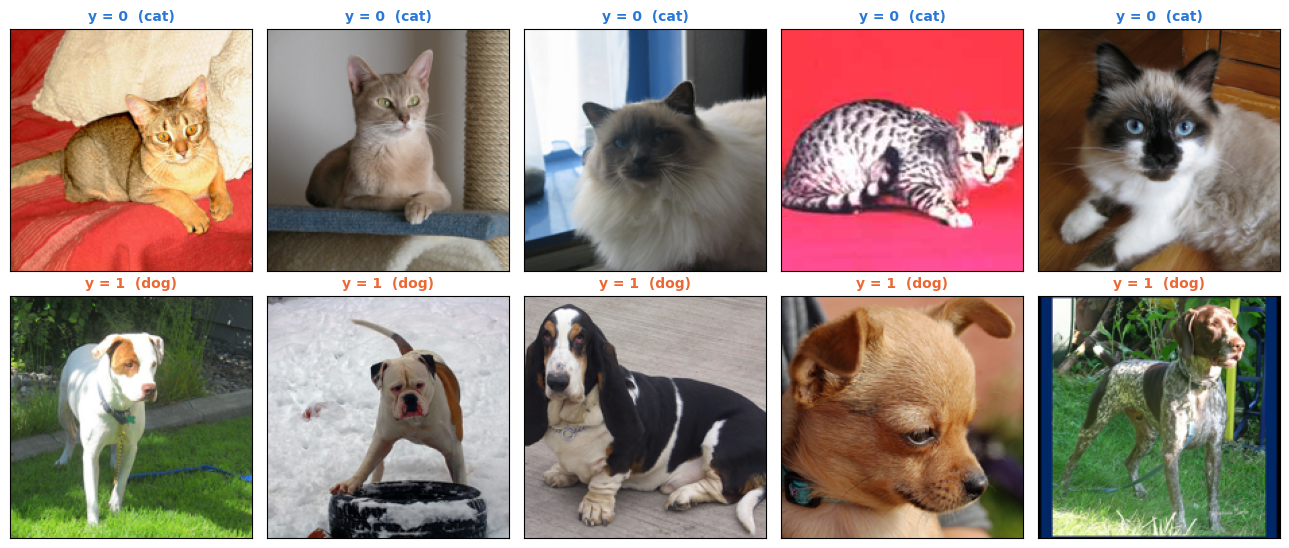

In [ ]:
# Get the data: download the pet photos, label each one cat (0) or dog (1), and split them up

# Rescale colors the way ResNet's training photos were rescaled (μ = average, σ = spread)
normalise = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])   # μ and σ per channel
pets = OxfordIIITPet(DATA, split="trainval", download=True)     # 37 breeds
to_binary = lambda breed: 0 if IS_CAT[breed] else 1             # 37 breeds -> one bit

# Download the Oxford-IIIT Pet dataset (about 800 MB, only the first time)
pets = OxfordIIITPet(DATA, split="trainval", download=True)     # 37 breeds
OxfordIIITPet(DATA, split="test", download=True)

# 12 breeds are cats and the other 25 are dogs, so each breed becomes 0 (cat) or 1 (dog)
CAT_BREEDS = {"Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
              "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx"}
IS_CAT  = [breed in CAT_BREEDS for breed in pets.classes]       # 12 of the 37
CLASSES = ["cat", "dog"]
to_binary = lambda breed: 0 if IS_CAT[breed] else 1             # 37 breeds -> one bit


# How each photo is prepared before the model sees it
# Training: a random crop and sometimes a mirror flip, so every epoch looks a little different
train_tf = transforms.Compose([transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalise])
# Checking: the same resize and center crop every time, so scores are fair
eval_tf  = transforms.Compose([transforms.Resize(202), transforms.CenterCrop(IMG_SIZE),
                               transforms.ToTensor(), normalise])

# Helper: the dataset with the preparation steps and cat/dog labels attached
def pet_data(split, tf):
    return OxfordIIITPet(DATA, split=split, transform=tf, target_transform=to_binary)

# Shuffle once, then split: 1600 photos to learn from, 600 to check progress on
# The test photos stay untouched until the very end
N_TRAIN, N_VAL = 1600, 600
order    = torch.randperm(len(pets), generator=torch.Generator().manual_seed(SEED)).tolist()
train_ds = Subset(pet_data("trainval", train_tf), order[:N_TRAIN])
val_ds   = Subset(pet_data("trainval", eval_tf), order[N_TRAIN:N_TRAIN + N_VAL])
test_ds  = pet_data("test", eval_tf)

# Print the split sizes and how many cats and dogs there are
labels = np.array([to_binary(y) for y in pets._labels])
print(f"train {N_TRAIN}   val {N_VAL}   test {len(test_ds)} (held out)")
print(f"trainval balance:  cats {(labels == 0).sum()}   dogs {(labels == 1).sum()}")

# Show 5 cats on the top row and 5 dogs on the bottom row
fig, axes = plt.subplots(2, 5, figsize=(13, 5.6))
paths = np.array(pets._images)
for row, y in enumerate((0, 1)):
    for ax, p in zip(axes[row], paths[labels == y][[3, 40, 120, 260, 430]]):
        ax.imshow(ImageOps.fit(Image.open(p).convert("RGB"), (180, 180)))
        ax.set_title(f"y = {y}  ({CLASSES[y]})", fontsize=10,
                     color="#2a78d6" if y == 0 else "#eb6834", weight="bold")
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Training with a certain set of cats and dogs, holding out some of them for evaluation

## Labels: 0 is cat, 1 is dog

Great. Now let's go ahead and start playing with some neural networks!

# Train the model. 

Epoch 1/5 | Step 10 | Real-Time Loss: 0.5418
Epoch 1/5 | Step 20 | Real-Time Loss: 0.5213
Epoch 1/5 | Step 30 | Real-Time Loss: 0.5155
Epoch 1/5 | Step 40 | Real-Time Loss: 0.3450
Epoch 1/5 | Step 50 | Real-Time Loss: 0.3342
--- Completed Epoch 1 | Val Acc: 0.8983 ---
Epoch 2/5 | Step 60 | Real-Time Loss: 0.3306
Epoch 2/5 | Step 70 | Real-Time Loss: 0.2530
Epoch 2/5 | Step 80 | Real-Time Loss: 0.2061
Epoch 2/5 | Step 90 | Real-Time Loss: 0.1860
Epoch 2/5 | Step 100 | Real-Time Loss: 0.1515
--- Completed Epoch 2 | Val Acc: 0.8933 ---
Epoch 3/5 | Step 110 | Real-Time Loss: 0.2547
Epoch 3/5 | Step 120 | Real-Time Loss: 0.2098
Epoch 3/5 | Step 130 | Real-Time Loss: 0.2383
Epoch 3/5 | Step 140 | Real-Time Loss: 0.3379
Epoch 3/5 | Step 150 | Real-Time Loss: 0.1782
--- Completed Epoch 3 | Val Acc: 0.9417 ---
Epoch 4/5 | Step 160 | Real-Time Loss: 0.1164
Epoch 4/5 | Step 170 | Real-Time Loss: 0.0972
Epoch 4/5 | Step 180 | Real-Time Loss: 0.1065
Epoch 4/5 | Step 190 | Real-Time Loss: 0.1328
Epo

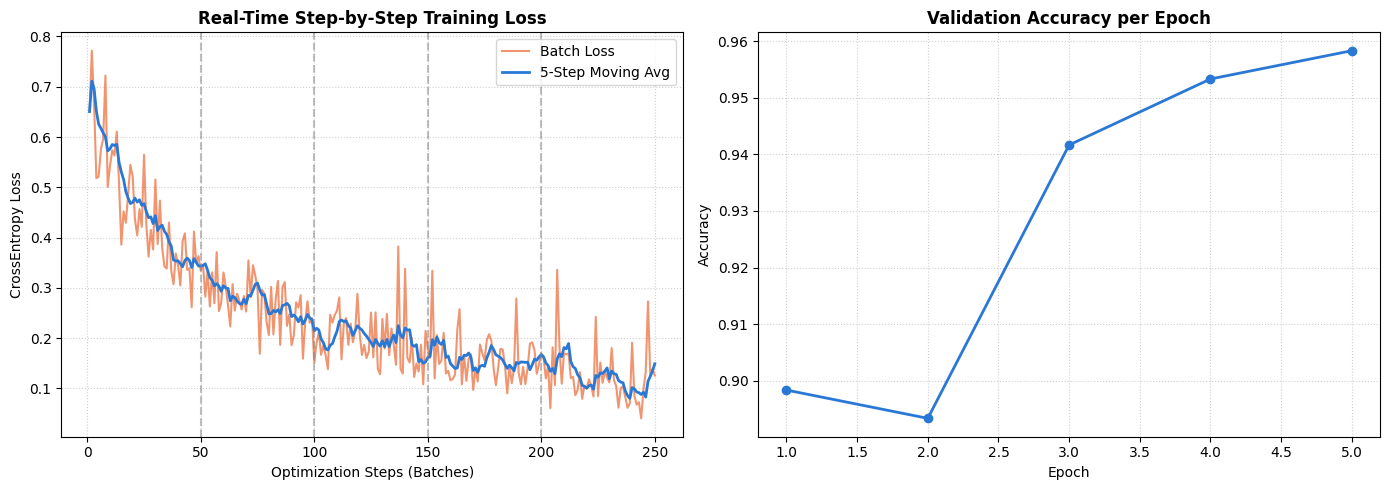

In [ ]:
# Train ResNet-18 to tell cats from dogs, then plot how it went
# This cell runs on its own: it loads its own libraries, data and model

# 1. Libraries and settings, the same as at the top of the notebook
import torch, torch.nn as nn, torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights

SEED, DATA, IMG_SIZE = 0, Path("data"), 128
torch.manual_seed(SEED)                 # same random start every run

# 2. The data, prepared exactly like the data cell above
# Pet photos labeled 0 (cat) or 1 (dog). The download only happens the first time
pets = OxfordIIITPet(DATA, split="trainval", download=True)
CAT_BREEDS = {"Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
              "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx"}
IS_CAT = [breed in CAT_BREEDS for breed in pets.classes]
to_binary = lambda breed: 0 if IS_CAT[breed] else 1

# Random crops and flips for training, a plain center crop for checking
normalise = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
train_tf = transforms.Compose([transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
                               transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalise])
eval_tf  = transforms.Compose([transforms.Resize(202), transforms.CenterCrop(IMG_SIZE),
                               transforms.ToTensor(), normalise])

def pet_data(split, tf):
    return OxfordIIITPet(DATA, split=split, transform=tf, target_transform=to_binary)

# 1600 photos to learn from, 600 to check progress on
N_TRAIN, N_VAL = 1600, 600
order    = torch.randperm(len(pets), generator=torch.Generator().manual_seed(SEED)).tolist()
train_ds = Subset(pet_data("trainval", train_tf), order[:N_TRAIN])
val_ds   = Subset(pet_data("trainval", eval_tf), order[N_TRAIN:N_TRAIN + N_VAL])

# 3. The model
# Load ResNet-18, already trained on over a million photos (ImageNet)
# Loading it here means every run starts fresh, not from where the last run left off
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Where the training runs: an NVIDIA GPU (cuda) if there is one, otherwise the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Swap ResNet's last layer (1000 ImageNet classes) for a new one with 2 outputs: cat and dog
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# The loss scores how wrong the guesses are. The optimizer nudges the weights to lower it
# lr is the nudge size. It's tiny, so the model keeps what it already learned
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Loaders hand out photos in batches of 32. Training photos get reshuffled every epoch
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 4. Train, keeping a record of progress for the plots
step_losses = []        # loss after every batch
epoch_val_accs = []     # validation accuracy after every epoch
step_counter = 0        # batches so far
step_ticks = []         # the step where each epoch ends

EPOCHS = 5              # 1 epoch = one pass through all 1600 training photos

for epoch in range(EPOCHS):
    model.train()       # switch to training mode

    # Learn from one batch of 32 photos at a time
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()               # clear the nudges from the last batch
        outputs = model(images)             # guess: 2 scores per photo
        loss = criterion(outputs, labels)   # how wrong were the guesses?

        loss.backward()                     # work out which way to nudge each weight
        optimizer.step()                    # nudge them

        # Save this batch's loss for the plot
        current_loss = loss.item()
        step_losses.append(current_loss)
        step_counter += 1

        # Print an update every 10 batches
        if step_counter % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Step {step_counter} | Real-Time Loss: {current_loss:.4f}")

    step_ticks.append(step_counter)

    # End of the epoch: check on the 600 validation photos, which the model never learns from
    model.eval()        # switch to prediction mode
    val_correct = 0
    val_total = 0

    with torch.no_grad():                   # only checking, so skip the training bookkeeping
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            _, val_preds = torch.max(val_outputs, 1)    # the higher score wins: 0 = cat, 1 = dog
            val_correct += (val_preds == val_labels).sum().item()
            val_total += val_labels.size(0)

    val_acc = val_correct / val_total       # share of photos it got right
    epoch_val_accs.append(val_acc)
    print(f"--- Completed Epoch {epoch+1} | Val Acc: {val_acc:.4f} ---")

# 5. Plot the loss (left) and the validation accuracy (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: the loss after every batch. Lower is better
ax1.plot(range(1, step_counter + 1), step_losses, color="#eb6834", alpha=0.7, label="Batch Loss")
# The raw line is bumpy, so draw a smoothed one on top: each point averages the last few losses
window = 5
if len(step_losses) >= window:
    smoothed = [sum(step_losses[max(0, i-window):i+1])/len(step_losses[max(0, i-window):i+1]) for i in range(len(step_losses))]
    ax1.plot(range(1, step_counter + 1), smoothed, color="#2a78d6", linewidth=2, label="5-Step Moving Avg")

# Dashed lines mark where one epoch ends and the next begins
for tick in step_ticks[:-1]:
    ax1.axvline(x=tick, color="gray", linestyle="--", alpha=0.5)

ax1.set_title("Real-Time Step-by-Step Training Loss", fontweight="bold")
ax1.set_xlabel("Optimization Steps (Batches)")
ax1.set_ylabel("CrossEntropy Loss")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

# Right: validation accuracy after each epoch. Higher is better
ax2.plot(range(1, EPOCHS + 1), epoch_val_accs, marker="o", color="#2a78d6", linewidth=2)
ax2.set_title("Validation Accuracy per Epoch", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# Model trained. We use something called the loss function to check how it went. 

# CrossEntropyLoss

**The idea**

- Measures how far off the network's predicted probabilities are from the true class label (cat = 0, dog = 1)
- If the model is confident and correct, loss is near **0**
- If the model is confident but WRONG, loss skyrockets to penalize the mistake heavily

$$
\text{Loss} \;=\; -\log(P_{\text{correct class}})
$$

- $P_{\text{correct class}}$ — the predicted probability assigned to the actual true target label
- Softmax converts raw output scores (logits) into probabilities that add up to 1 (e.g., $80\%$ cat, $20\%$ dog)
- $\log(\dots)$ — the natural logarithm; taking $-\log(1.0) = 0$, while $-\log(0.01) = 4.6$


$$
\frac{\partial \text{Loss}}{\partial z_i} \;=\; P_i - Y_i
$$

- $z_i$ — the raw, unnormalized prediction score (logit) for class $i$
- $P_i$ — the probability predicted for class $i$
- $Y_i$ — the actual target ($1$ if it is the correct class, $0$ otherwise)
- **During backpropagation:** The gradient simplifies to simply **(Predicted Probability - True Target)**, providing an intuitive, direct push to adjust the weights in the right direction

Now we've trained our first loop. Try not to get too overwhelmed with all this code. I will be going through it step by step.

# Use the model to predict. 

Test Set Accuracy: 96.27% (3532/3669)


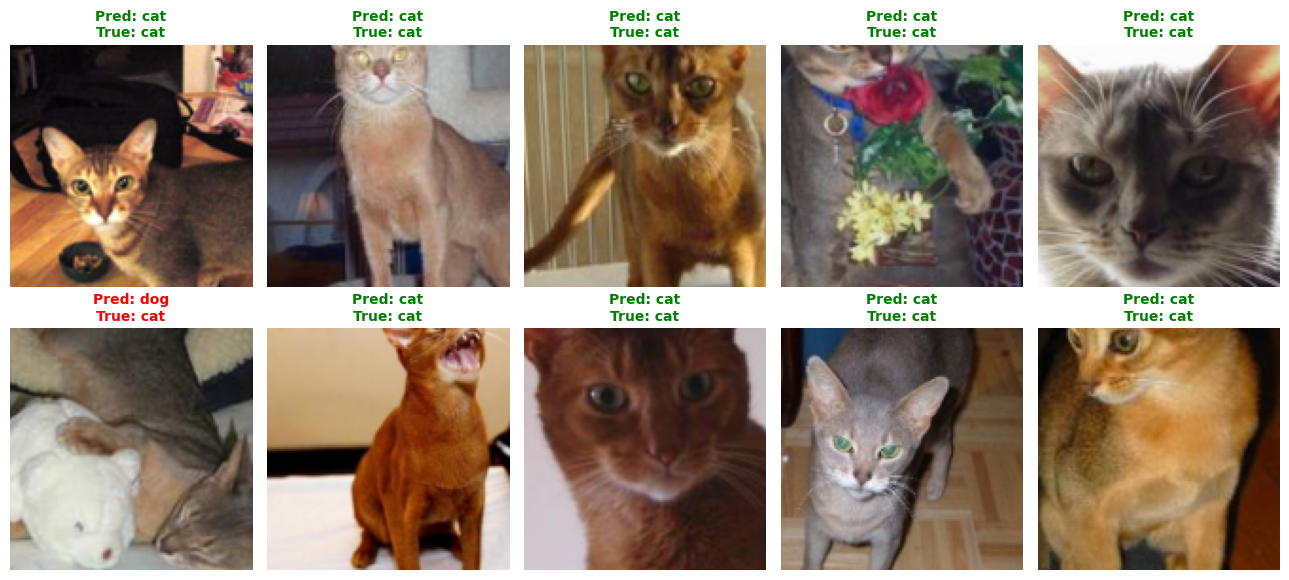

In [ ]:
# Final exam: run the trained model on test photos it has never seen, then look at some guesses

# 1. Predict every test photo and count how many it gets right
model.eval()                 # switch to prediction mode
test_correct = 0
test_total = 0

# Keep the photos, guesses and true labels for the pictures below
all_test_images = []
all_test_preds = []
all_test_labels = []

with torch.no_grad():        # only predicting, so skip the training bookkeeping
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)     # the higher score wins: 0 = cat, 1 = dog

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        # Save this batch, moved back to the CPU for plotting
        all_test_images.append(images.cpu())
        all_test_preds.append(preds.cpu())
        all_test_labels.append(labels.cpu())

test_accuracy = test_correct / test_total
print(f"Test Set Accuracy: {test_accuracy * 100:.2f}% ({test_correct}/{test_total})")

# 2. Show 10 test photos with the model's guess and the right answer
sample_images = all_test_images[0]     # the first batch
sample_preds = all_test_preds[0]
sample_labels = all_test_labels[0]

# Undo the normalization so the colors look natural again
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(sample_images):      # stop early if the batch has fewer than 10 photos
        break

    # Turn the tensor back into a picture: keep values between 0 and 1, move color to the end
    img = denormalize(sample_images[i]).clamp(0, 1).permute(1, 2, 0).numpy()
    pred_class = CLASSES[sample_preds[i].item()]
    true_class = CLASSES[sample_labels[i].item()]

    # Green title if the guess is right, red if it's wrong
    is_correct = sample_preds[i] == sample_labels[i]
    title_color = "green" if is_correct else "red"

    ax.imshow(img)
    ax.set_title(f"Pred: {pred_class}\nTrue: {true_class}", color=title_color, fontsize=10, weight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Finished. Now you trained your own neural network!

Please reach out if you ever want to get in touch again. @douzog
